In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def tanh(z):
    return np.tanh(z)

def dtanh(a):
    return 1 - a**2

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def dsigmoid(a):
    return a * (1 - a)

def relu(z):
    return np.maximum(0, z)

def drelu(a):
    return (a > 0).astype(float)

ACT = {
    "tanh": (tanh, dtanh),
    "sigmoid": (sigmoid, dsigmoid),
    "relu": (relu, drelu)
}

In [4]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def one_hot(y, num_classes):
    oh = np.zeros((len(y), num_classes))
    oh[np.arange(len(y)), y] = 1
    return oh

In [5]:
def init_params(layers):
    params = []

    for i in range(1, len(layers)):

        # Xavier Initialization
        limit = np.sqrt(1 / layers[i - 1])

        W = np.random.randn(layers[i], layers[i - 1]) * limit
        b = np.zeros((layers[i], 1))

        params.append({
            "W": W,
            "b": b
        })

    return params


In [7]:
def forward(X, params, activations):
    A = X
    cache = [{"A": X}]
    for l in range(len(params)):
        W = params[l]["W"]
        b = params[l]["b"]
        Z = A @ W.T + b.T
        if l == len(params) - 1:
            A = softmax(Z)
        else:
            act_fn = ACT[activations[l]][0]
            A = act_fn(Z)
        cache.append({
            "Z": Z,
            "A": A
        })
    return A, cache

In [8]:
def loss(y, yhat):
    eps = 1e-8
    yhat = np.clip(yhat, eps, 1 - eps)
    return -np.mean(np.sum(y * np.log(yhat), axis=1))

In [9]:
def backward(y, yhat, params, cache, activations):
    grads = []
    m = y.shape[0]
    dZ = yhat - y
    for l in reversed(range(len(params))):
        A_prev = cache[l]["A"]
        W = params[l]["W"]
        dW = (1 / m) * (dZ.T @ A_prev)
        db = (1 / m) * np.sum(dZ, axis=0, keepdims=True).T
        grads.insert(0, {
            "dW": dW,
            "db": db
        })
        if l > 0:
            dA_prev = dZ @ W
            A_prev_act = cache[l]["A"]
            deriv_fn = ACT[activations[l - 1]][1]
            dZ = dA_prev * deriv_fn(A_prev_act)
    return grads

In [10]:
def update(params, grads, lr):
    for l in range(len(params)):
        params[l]["W"] -= lr * grads[l]["dW"]
        params[l]["b"] -= lr * grads[l]["db"]
    return params

In [11]:
def metrics(y_true, y_pred):
    y_true_cls = np.argmax(y_true, axis=1)
    y_pred_cls = np.argmax(y_pred, axis=1)
    acc = np.mean(y_true_cls == y_pred_cls)
    num_classes = y_true.shape[1]
    precisions = []
    recalls = []
    f1s = []
    for c in range(num_classes):
        TP = np.sum((y_pred_cls == c) & (y_true_cls == c))
        FP = np.sum((y_pred_cls == c) & (y_true_cls != c))
        FN = np.sum((y_pred_cls != c) & (y_true_cls == c))
        precision = TP / (TP + FP + 1e-8)
        recall = TP / (TP + FN + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
    return (
        acc,
        np.mean(precisions),
        np.mean(recalls),
        np.mean(f1s)
    )

In [12]:
def train(X,y,layers,activations,epochs=100,lr=0.01):
    params = init_params(layers)
    losses = []
    for i in range(epochs):
        yhat, cache = forward(X, params, activations)
        l = loss(y, yhat)
        losses.append(l)
        grads = backward(y, yhat, params, cache, activations)
        params = update(params, grads, lr)
    yhat, _ = forward(X, params, activations)
    acc, p, r, f1 = metrics(y, yhat)
    return params, losses, acc, p, r, f1



ACTIVATION FUNCTION : TANH


------------------------------------------------------------
Experiment 1 | Activation=tanh | LR=0.001 | Epochs=50
Final Loss     : 1.703057
Accuracy       : 0.197800
Precision      : 0.199248
Recall         : 0.198152
F1 Score       : 0.193829


------------------------------------------------------------
Experiment 2 | Activation=tanh | LR=0.001 | Epochs=100
Final Loss     : 1.726184
Accuracy       : 0.201600
Precision      : 0.199983
Recall         : 0.201398
F1 Score       : 0.193517


------------------------------------------------------------
Experiment 3 | Activation=tanh | LR=0.001 | Epochs=200
Final Loss     : 1.727841
Accuracy       : 0.193600
Precision      : 0.193281
Recall         : 0.193676
F1 Score       : 0.187608


------------------------------------------------------------
Experiment 4 | Activation=tanh | LR=0.001 | Epochs=500
Final Loss     : 1.667282
Accuracy       : 0.204000
Precision      : 0.204833
Recall         : 0.204261
F1 Sco

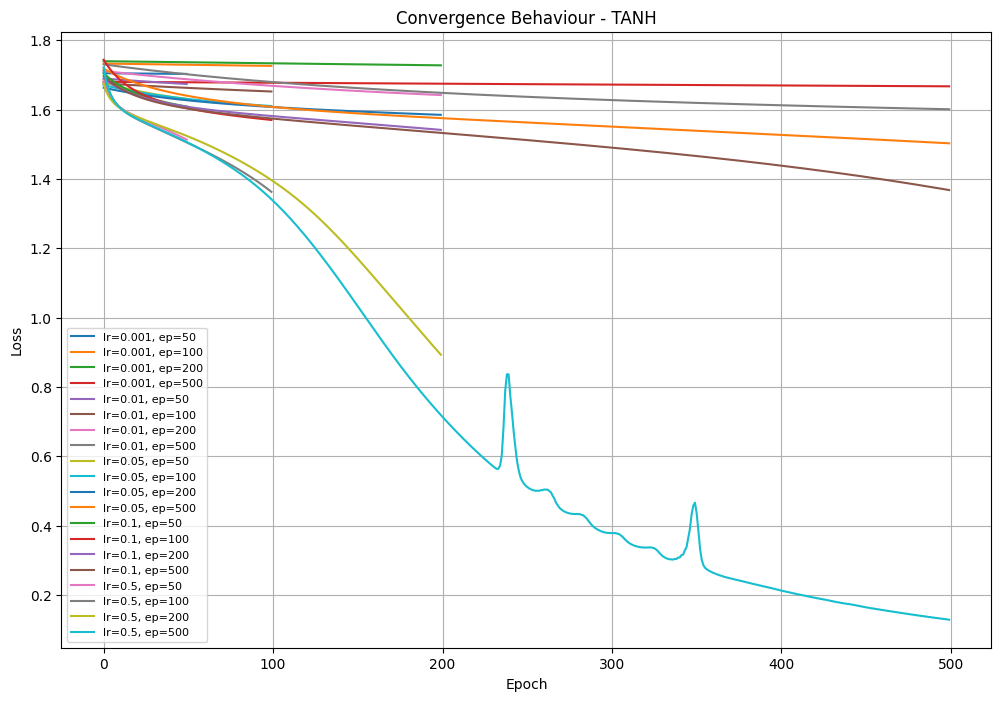



ACTIVATION FUNCTION : RELU


------------------------------------------------------------
Experiment 1 | Activation=relu | LR=0.001 | Epochs=50
Final Loss     : 1.771420
Accuracy       : 0.199000
Precision      : 0.196795
Recall         : 0.199086
F1 Score       : 0.133603


------------------------------------------------------------
Experiment 2 | Activation=relu | LR=0.001 | Epochs=100
Final Loss     : 1.661540
Accuracy       : 0.203800
Precision      : 0.205432
Recall         : 0.203358
F1 Score       : 0.175187


------------------------------------------------------------
Experiment 3 | Activation=relu | LR=0.001 | Epochs=200
Final Loss     : 1.755605
Accuracy       : 0.198800
Precision      : 0.196771
Recall         : 0.200918
F1 Score       : 0.120427


------------------------------------------------------------
Experiment 4 | Activation=relu | LR=0.001 | Epochs=500
Final Loss     : 1.668641
Accuracy       : 0.204700
Precision      : 0.191860
Recall         : 0.203781
F1 Sco

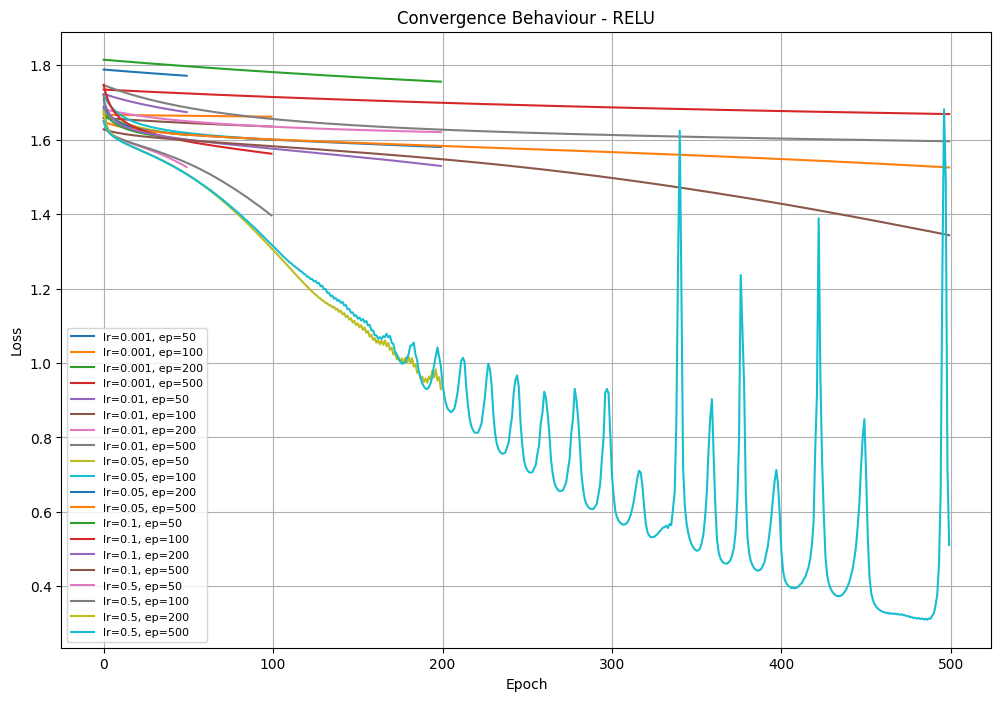



ACTIVATION FUNCTION : SIGMOID


------------------------------------------------------------
Experiment 1 | Activation=sigmoid | LR=0.001 | Epochs=50
Final Loss     : 1.650622
Accuracy       : 0.201600
Precision      : 0.040320
Recall         : 0.200000
F1 Score       : 0.067111


------------------------------------------------------------
Experiment 2 | Activation=sigmoid | LR=0.001 | Epochs=100
Final Loss     : 1.667013
Accuracy       : 0.196600
Precision      : 0.039320
Recall         : 0.200000
F1 Score       : 0.065720


------------------------------------------------------------
Experiment 3 | Activation=sigmoid | LR=0.001 | Epochs=200
Final Loss     : 1.684090
Accuracy       : 0.199300
Precision      : 0.073489
Recall         : 0.198491
F1 Score       : 0.073314


------------------------------------------------------------
Experiment 4 | Activation=sigmoid | LR=0.001 | Epochs=500
Final Loss     : 1.635467
Accuracy       : 0.199100
Precision      : 0.039820
Recall         : 

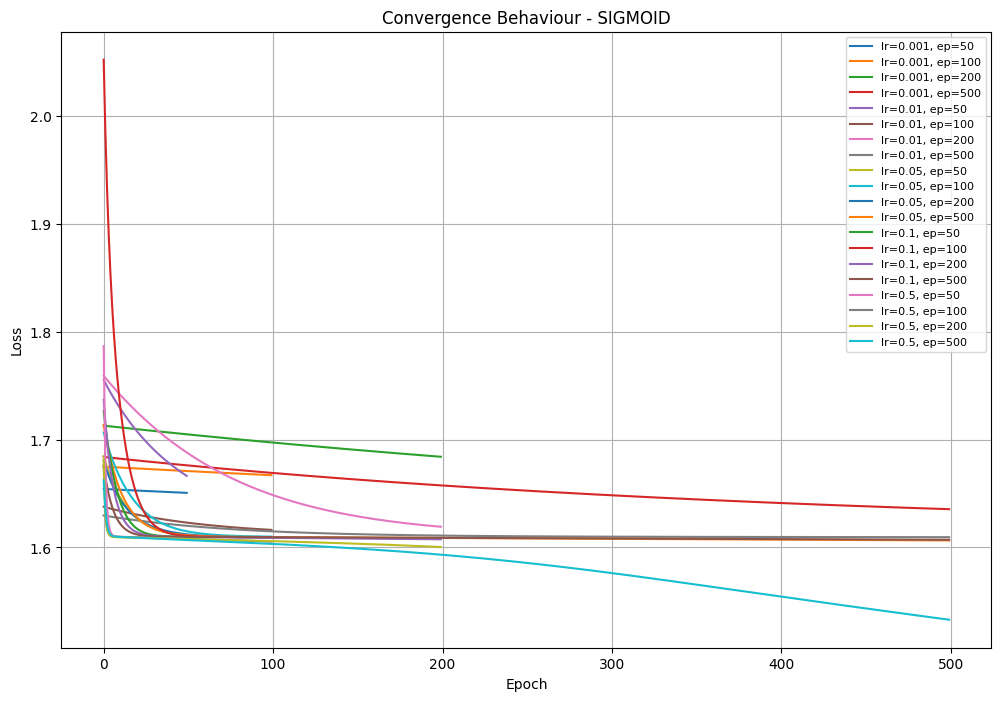

In [13]:
if __name__ == "__main__":
    np.random.seed(42)

    samples = 10000
    features = 600
    classes = 5
    X = np.random.randn(samples, features)
    y_raw = np.random.randint(0, classes, size=samples)
    y = one_hot(y_raw, classes)


    layers = [600, 20, 10, 5]

    learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]

    epoch_list = [50, 100, 200, 500]

    activations_to_test = ["tanh", "relu", "sigmoid"]


    for activation_name in activations_to_test:

        print("\n")
        print("=" * 70)
        print(f"ACTIVATION FUNCTION : {activation_name.upper()}")
        print("=" * 70)

        plt.figure(figsize=(12, 8))

        experiment_no = 1

        for lr in learning_rates:

            for epochs in epoch_list:

                print("\n")
                print("-" * 60)

                print(
                    f"Experiment {experiment_no} | "
                    f"Activation={activation_name} | "
                    f"LR={lr} | Epochs={epochs}"
                )

                activations = [activation_name, activation_name]

                params, losses, acc, p, r, f1 = train(
                    X,
                    y,
                    layers,
                    activations,
                    epochs=epochs,
                    lr=lr
                )

                print(f"Final Loss     : {losses[-1]:.6f}")
                print(f"Accuracy       : {acc:.6f}")
                print(f"Precision      : {p:.6f}")
                print(f"Recall         : {r:.6f}")
                print(f"F1 Score       : {f1:.6f}")


                plt.plot(
                    losses,
                    label=f"lr={lr}, ep={epochs}"
                )

                experiment_no += 1

        plt.title(
            f"Convergence Behaviour - {activation_name.upper()}"
        )

        plt.xlabel("Epoch")

        plt.ylabel("Loss")

        plt.legend(fontsize=8)

        plt.grid(True)

        plt.show()

In [19]:
samples = 200
features = 100
classes = 10
X = np.random.randn(samples, features)
y_raw = np.random.randint(0, classes, size=samples)
y = one_hot(y_raw, classes)
layers = [100, 20, 10]

activations = ["tanh"]
params, losses, acc, p, r, f1 = train(
    X,
    y,
    layers,
    activations,
    epochs=100,
    lr=0.01
)
print("Loss:", losses[-1])
print("Accuracy:", acc)
print("Precision:", p)
print("Recall:", r)
print("F1:", f1)


Loss: 2.190341381059275
Accuracy: 0.2
Precision: 0.19192784983291283
Recall: 0.1960846969343995
F1: 0.19136142014443086
